<a href="https://colab.research.google.com/github/subham-28/PyTorch/blob/main/ANN_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import matplotlib.pyplot as plt

In [3]:
torch.manual_seed(42)

In [4]:
df=pd.read_csv("fmnist_small.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,...,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,125,72,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,3,0,2,0,0,210,228,228,233,0,0,0,0,0,0,0,0,0,31,81,133,184,201,190,117,0,0,2,1,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,0,43,117,34,15,24,33,117,80,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,51,144,152,...,157,158,161,148,159,58,0,6,0,0,0,0,0,0,0,0,0,4,0,60,143,143,148,146,152,152,148,148,147,145,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,0,0,0,2,0,33,114,37,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,...,11,17,13,13,11,10,7,5,5,5,7,0,0,0,1,0,0,41,69,88,86,94,106,114,118,47,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,0,2,0,58,145,114,10,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,...,165,153,155,134,143,172,215,62,0,0,0,0,0,0,0,0,10,190,178,194,209,211,209,205,211,215,213,217,225,228,213,203,174,151,188,10,0,0,0,0


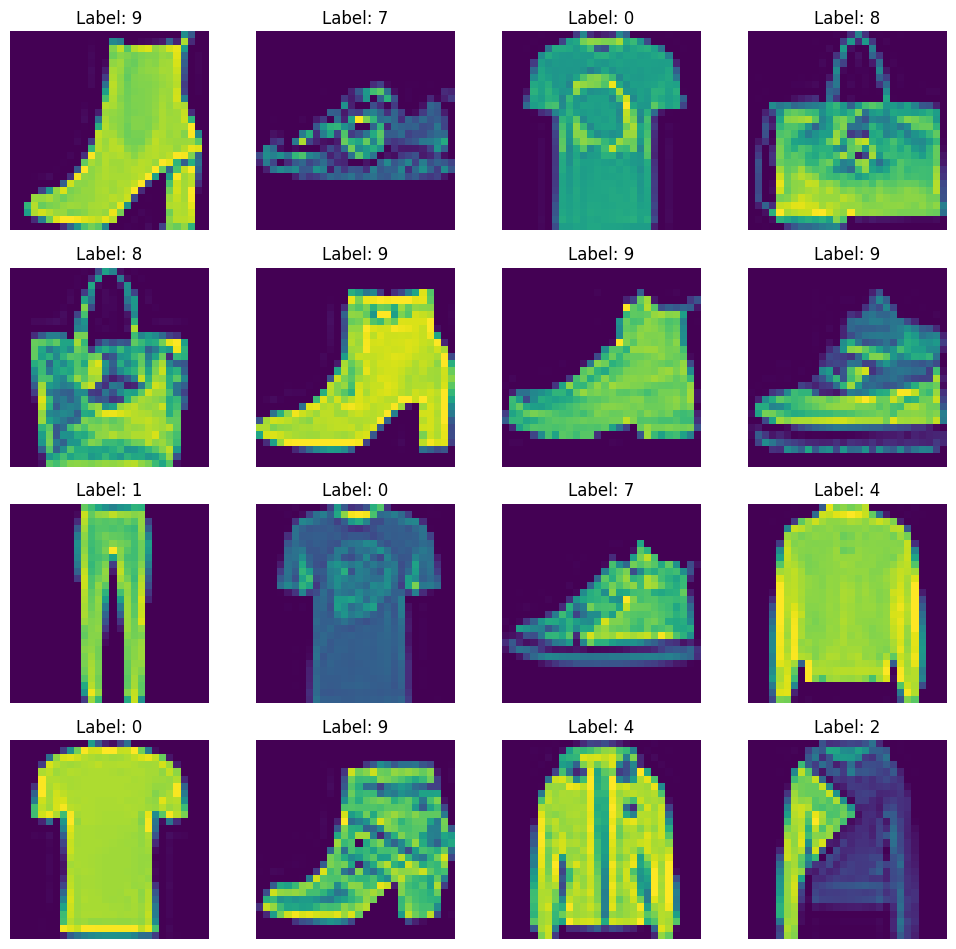

In [6]:
fig, axes=plt.subplots(nrows=4, ncols=4, figsize=(10,10))

for i,ax in enumerate(axes.flat):
  img=df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis("off")
  ax.set_title(f"Label: {df.iloc[i,0]}")
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [7]:
x=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [8]:
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.2, random_state=42)

In [9]:
#scaling
x_train=x_train/255.0
x_test=x_test/255.0

In [10]:
#custom dataset class
class CustomDataset(Dataset):
  def __init__(self,features,labels):
    super().__init__()
    self.features=torch.tensor(features, dtype=torch.float32)
    self.labels=torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,idx):
    return self.features[idx], self.labels[idx]

In [11]:
train_dataset=CustomDataset(x_train, y_train)
test_dataset=CustomDataset(x_test, y_test)

In [15]:
len(train_dataset)

4800

In [16]:
#create train and test loader
train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=32, shuffle=False)

In [21]:
#define nn
class MyNN(nn.Module):
  def __init__(self,num_features):
    super().__init__()
    self.model=nn.Sequential(
      nn.Linear(num_features,128),
      nn.ReLU(),
      nn.Linear(128,64),
      nn.ReLU(),
      nn.Linear(64,10)
    )

  def forward(self,features):
    out=self.model(features)
    return out

In [22]:
epochs=100
learning_rate=0.1

In [24]:
# create model
model=MyNN(x_train.shape[1])

#loss func
loss_function=nn.CrossEntropyLoss()

#define optimizer
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)

In [26]:
#training loop
for epoch in range(epochs):
  total_epoch_loss=0
  for batch_features, batch_labels in train_loader:

    #forward pass
    y_pred=model(batch_features)

    #loss
    loss = loss_function(y_pred,batch_labels)

    #zero gradient
    optimizer.zero_grad()

    #backward pass
    loss.backward()

    #update params
    optimizer.step()

    #print loss
    total_epoch_loss+=loss.item()
  total_epoch_loss=total_epoch_loss/len(train_loader)
  print(f"Epoch: {epoch+1}/{epochs} Loss: {total_epoch_loss}")

Epoch: 1/100 Loss: 0.006229207134844425
Epoch: 2/100 Loss: 0.006631034018937498
Epoch: 3/100 Loss: 0.003924689549021423
Epoch: 4/100 Loss: 0.0028726571351580786
Epoch: 5/100 Loss: 0.00258101531023082
Epoch: 6/100 Loss: 0.002449649287736975
Epoch: 7/100 Loss: 0.002477287073173405
Epoch: 8/100 Loss: 0.0020243992147152313
Epoch: 9/100 Loss: 0.00184344007827652
Epoch: 10/100 Loss: 0.001800775215572988
Epoch: 11/100 Loss: 0.0016311089091565615
Epoch: 12/100 Loss: 0.001583426121554415
Epoch: 13/100 Loss: 0.0014910049792767192
Epoch: 14/100 Loss: 0.0016132139560068026
Epoch: 15/100 Loss: 0.001465759955268974
Epoch: 16/100 Loss: 0.0015915396149406055
Epoch: 17/100 Loss: 0.00128576107158248
Epoch: 18/100 Loss: 0.001203041912522167
Epoch: 19/100 Loss: 0.0011939045749992754
Epoch: 20/100 Loss: 0.0011646061432838905
Epoch: 21/100 Loss: 0.0010859802235790993
Epoch: 22/100 Loss: 0.001078181502816733
Epoch: 23/100 Loss: 0.0010835184875759296
Epoch: 24/100 Loss: 0.0010345951992591534
Epoch: 25/100 Los

In [27]:
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [28]:
#evaluation
total=0
correct=0

with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    y_pred=model(batch_features)
    _, predicted=torch.max(y_pred,1)
    total+=batch_labels.shape[0]
    correct+=(predicted==batch_labels).sum().item()

print(f"Accuracy: {correct/total}")

Accuracy: 0.8391666666666666
